In [1]:
import pandas as pd
import json

In [2]:
train = json.load(open("../data/splitted_data/fold_1/train.json","r"))
test = json.load(open("../data/splitted_data/fold_1/test.json","r"))

In [3]:
categories = ["Drug","Alcohol",'Adherence','Concern','Education','Employment','Financial','Healthcare','Insurance','Literacy','Living','MentalHealth','Recommendation','Smoke','Social','SubstanceUse','Transportation','Trauma','overall']

In [10]:
len(train)+len(test)

2836

In [4]:
cnt_dict = {}
for i in categories:
    cnt_dict[i] = 0

In [5]:
for i in train:
    for j in i['ner_tags']:
        if j.startswith("B"):
            j = j.lstrip("B-")
            cnt_dict[j] += 1
for i in test:
    for j in i['ner_tags']:
        if j.startswith("B"):
            j = j.lstrip("B-")
            cnt_dict[j] += 1


In [6]:
categories = []
frequencies = []
for (i, j) in sorted(cnt_dict.items(), key=lambda item: item[1]):
    if i == 'overall' or i == 'Drug' or i == "Alcohol":
        continue
    else:
        if i == "SubstanceUse":
            j = j + 4
        categories.append(i)
        frequencies.append(j)


In [19]:
pd.DataFrame([categories,frequencies]).T.sort_values(by=1)

,0,1
0,Smoke,41
1,Insurance,60
2,Concern,66
3,SubstanceUse,80
4,Education,100
5,Transportation,106
6,MentalHealth,136
7,Literacy,140
8,Recommendation,142
9,Adherence,146


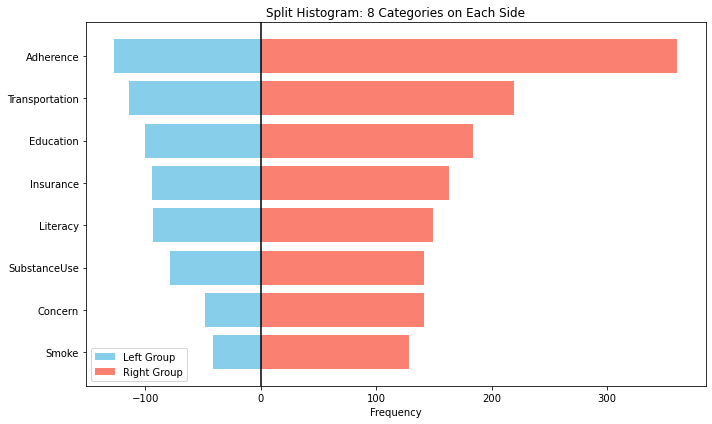

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# # Example data
# categories = [f'Cat{i+1}' for i in range(16)]
# frequencies = [10, 12, 8, 9, 11, 14, 7, 13, 15, 9, 12, 8, 6, 10, 14, 11]

# Split into left and right halves
left_cats = categories[:8]
right_cats = categories[8:]
left_freq = frequencies[:8]
right_freq = frequencies[8:]

# Convert to numpy for easier handling
y_pos = np.arange(8)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot left side (negative direction)
ax.barh(y_pos, [-f for f in left_freq], color='skyblue', label='Left Group')

# Plot right side (positive direction)
ax.barh(y_pos, right_freq, color='salmon', label='Right Group')

# Center y-axis at 0
ax.axvline(0, color='black')

# Customize ticks and labels
ax.set_yticks(y_pos)
ax.set_yticklabels(left_cats)  # You can also merge labels if you want paired ones
ax.set_xlabel('Frequency')
ax.set_title('Split Histogram: 8 Categories on Each Side')

# Add legend
ax.legend()

plt.tight_layout()
plt.show()